In [125]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

houses = pd.read_csv('data/bygningsbestand_2022.csv')
energy_profile = pd.read_csv('data/gjennomsnittlig_forbruk_2022.csv')

houses = houses.set_index('byggeaar')
energy_profile = energy_profile.set_index('byggeaar')
energy_profile


,Elektrisitet,"Ved, pellets og vedbriketter",Gass og fjernvarme
byggeaar,,,
1900,14385.0,2627.0,224.0
1901,14385.0,2627.0,224.0
1902,14385.0,2627.0,224.0
1903,14385.0,2627.0,224.0
1904,14385.0,2627.0,224.0
...,...,...,...
2018,12559.0,882.0,948.0
2019,12559.0,882.0,948.0
2020,12559.0,882.0,948.0


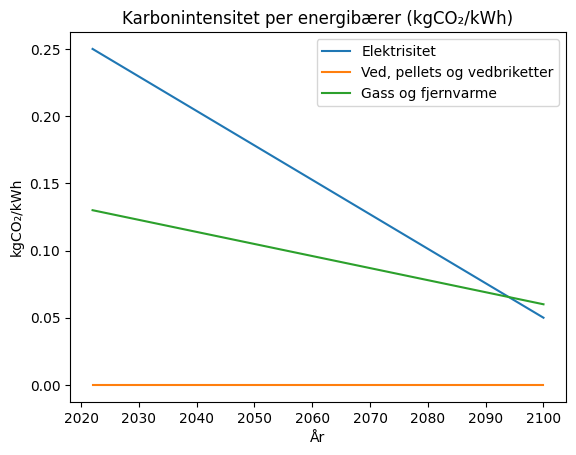

In [126]:
projection_years = np.arange(2022,2101)

carbon_intensity = pd.DataFrame({
    'Elektrisitet':                   np.linspace(0.250, 0.050, len(projection_years)),
    'Ved, pellets og vedbriketter':   np.full(len(projection_years), 0.0),
    'Gass og fjernvarme':             np.linspace(0.130, 0.060, len(projection_years)),
}, index=projection_years)

demoliton_rate = 0.002
new_houses =  5000

new_energy_profile = pd.DataFrame({
    'Elektrisitet':                   12000,
    'Ved, pellets og vedbriketter':   400,
    'Gass og fjernvarme':             300,
}, index=projection_years[1:])


plt.plot(projection_years, carbon_intensity['Elektrisitet'], label='Elektrisitet')
plt.plot(projection_years, carbon_intensity['Ved, pellets og vedbriketter'], label='Ved, pellets og vedbriketter')
plt.plot(projection_years, carbon_intensity['Gass og fjernvarme'], label='Gass og fjernvarme')
plt.title('Karbonintensitet per energibærer (kgCO₂/kWh)')
plt.xlabel('År')
plt.ylabel('kgCO₂/kWh')
plt.legend()
plt.show()


byggeaar
2018    7683.3
2019    7683.3
2020    7683.3
2021    3052.0
2022    3052.0
2023       0.0
2024       0.0
Name: 2022, dtype: float64

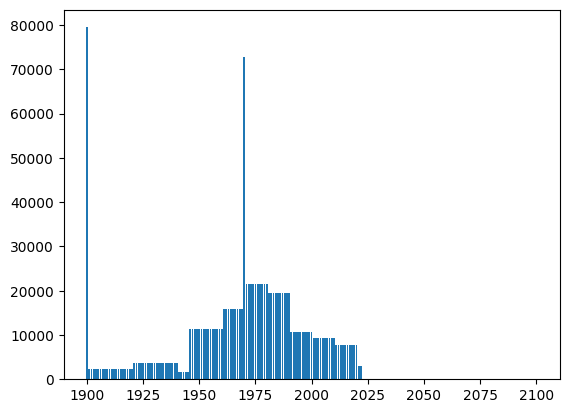

In [127]:
all_byggeaar = np.arange(1900,2101)
house_stock = pd.DataFrame(
    index=all_byggeaar,
    columns=projection_years,
    dtype=float
)
house_stock.index.name   = 'byggeaar'
house_stock.columns.name = 'projection'

house_stock.loc[:,:] = 0
house_stock.loc[:2022,2022] = houses['antall_boliger'] 


for yr in projection_years[1:]:
    house_stock.loc[:,yr] = house_stock.loc[:,yr-1]*(1-demoliton_rate)
    house_stock.loc[yr, yr] = new_houses

plt.bar(all_byggeaar, house_stock[2022])

house_stock.loc[2018:2024,2022]

In [128]:
combined_energy_profile = pd.concat([energy_profile, new_energy_profile])
combined_energy_profile.index.name = 'byggeaar'

pd.set_option('display.max_rows', 20)

print(combined_energy_profile)


          Elektrisitet  Ved, pellets og vedbriketter  Gass og fjernvarme
byggeaar                                                                
1900           14385.0                        2627.0               224.0
1901           14385.0                        2627.0               224.0
1902           14385.0                        2627.0               224.0
1903           14385.0                        2627.0               224.0
1904           14385.0                        2627.0               224.0
...                ...                           ...                 ...
2096           12000.0                         400.0               300.0
2097           12000.0                         400.0               300.0
2098           12000.0                         400.0               300.0
2099           12000.0                         400.0               300.0
2100           12000.0                         400.0               300.0

[201 rows x 3 columns]


In [129]:

energy_consumption = pd.DataFrame({
    'Elektrisitet':                   np.full(len(projection_years), np.nan),
    'Ved, pellets og vedbriketter':   np.full(len(projection_years), np.nan),
    'Gass og fjernvarme':             np.full(len(projection_years), np.nan),
}, index=projection_years)

energy_consumption

,Elektrisitet,"Ved, pellets og vedbriketter",Gass og fjernvarme
2022,NaN,NaN,NaN
2023,NaN,NaN,NaN
2024,NaN,NaN,NaN
2025,NaN,NaN,NaN
2026,NaN,NaN,NaN
...,...,...,...
2096,NaN,NaN,NaN
2097,NaN,NaN,NaN
2098,NaN,NaN,NaN
2099,NaN,NaN,NaN


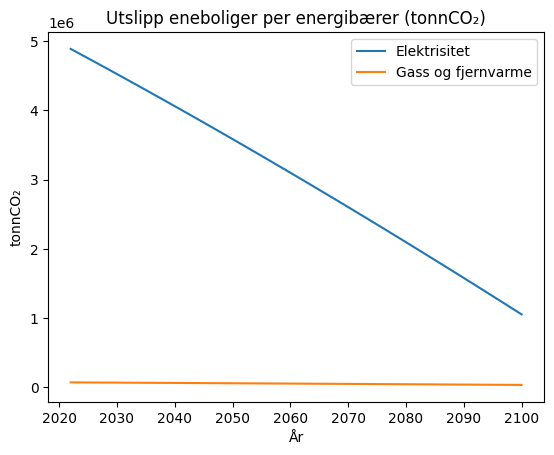

In [133]:
for yr in projection_years:
    energy_consumption.loc[yr] = house_stock.loc[:,yr].T@combined_energy_profile

energy_consumption.loc[2022]

utslipp = energy_consumption * carbon_intensity

plt.plot(projection_years, utslipp['Elektrisitet']/1e3, label='Elektrisitet')
plt.plot(projection_years, utslipp['Gass og fjernvarme']/1e3, label='Gass og fjernvarme')
plt.title('Utslipp eneboliger per energibærer (tonnCO₂)')
plt.xlabel('År')
plt.ylabel('tonnCO₂')
plt.legend()
plt.show()
